In [ ]:
#sanity check for gradcam

In [32]:
import sys
sys.path.append('D:/cxr-triage')

import torch
from src.models.densenet import DenseNetModel
from src.inference.gradcam import GradCAM

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DenseNetModel(num_classes=14, pretrained=False).to(DEVICE)
checkpoint = torch.load('D:/cxr-triage/checkpoints/clahe_320_logits_fix/best_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

gradcam = GradCAM(model)

# Confirm which layer is actually hooked
target_layer = model.model.features.denseblock4.denselayer16.conv2
print("Target layer:", target_layer)

# Run a dummy forward+backward to confirm activations are captured
dummy_input = torch.randn(1, 3, 320, 320).to(DEVICE)
heatmap = gradcam.generate(dummy_input, class_idx=0)

print("Heatmap shape:", heatmap.shape)
print("Heatmap min/max/mean:", heatmap.min(), heatmap.max(), heatmap.mean())
print("Activation shape captured:", gradcam.activations.shape)

Target layer: Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
Heatmap shape: (10, 10)
Heatmap min/max/mean: 0.0 0.0 0.0
Activation shape captured: torch.Size([1, 32, 10, 10])


In [33]:
import sys
sys.path.append('D:/cxr-triage')

import torch
from PIL import Image as PILImage
from src.models.densenet import DenseNetModel
from src.data.transforms import get_val_transforms
from src.inference.gradcam import GradCAM

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DenseNetModel(num_classes=14, pretrained=False).to(DEVICE)
checkpoint = torch.load('D:/cxr-triage/checkpoints/clahe_320_logits_fix/best_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

gradcam = GradCAM(model)
transform = get_val_transforms(image_size=320, use_clahe=True)

# Use a REAL image this time — e.g. the same Cardiomegaly case from before
img = PILImage.open("F:/X ray dataset/Second Version/images_001/images/00001333_000.png").convert('RGB')

img_tensor = transform(img).unsqueeze(0)

LABELS = ['Atelectasis','Consolidation','Infiltration','Pneumothorax','Edema',
          'Emphysema','Fibrosis','Effusion','Pneumonia','Pleural_Thickening',
          'Cardiomegaly','Nodule','Mass','Hernia']
class_idx = LABELS.index('Cardiomegaly')

heatmap = gradcam.generate(img_tensor.clone(), class_idx)

print("Heatmap shape:", heatmap.shape)
print("Heatmap min/max/mean:", heatmap.min(), heatmap.max(), heatmap.mean())
print("Activation shape captured:", gradcam.activations.shape)

Heatmap shape: (10, 10)
Heatmap min/max/mean: 0.0 1.0 0.039574813
Activation shape captured: torch.Size([1, 32, 10, 10])


In [11]:
import sys
sys.path.append('D:/cxr-triage')

import os
import torch
from PIL import Image as PILImage

from src.models.densenet import DenseNetModel
from src.data.transforms import get_val_transforms
from src.inference.gradcam import GradCAM

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGE_ROOT = "F:/X ray dataset/Second Version"
CHECKPOINT_PATH = "D:/cxr-triage/checkpoints/clahe_320_logits_fix/best_model.pth"
LABELS = ['Atelectasis','Consolidation','Infiltration','Pneumothorax','Edema',
          'Emphysema','Fibrosis','Effusion','Pneumonia','Pleural_Thickening',
          'Cardiomegaly','Nodule','Mass','Hernia']

model = DenseNetModel(num_classes=14, pretrained=False).to(DEVICE)
checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

transform = get_val_transforms(image_size=320, use_clahe=True)
gradcam = GradCAM(model)

print("Setup complete. Model loaded from epoch", checkpoint['epoch']+1, "| Best AUC:", checkpoint['best_auc'])

Setup complete. Model loaded from epoch 15 | Best AUC: 0.794292738974004


In [35]:



blank_cases = [
    ('00000032_000.png', 'Cardiomegaly'),
    ('00000013_011.png', 'Pneumothorax'),
    ('00000032_024.png', 'Edema'),
]
for img_name, finding in blank_cases:
    print(f"\n{'='*50}")
    print(f"Image: {img_name} | Finding: {finding}")

    image_path = None
    for folder in [f"images_{str(i).zfill(3)}" for i in range(1, 13)]:
        path = os.path.join(IMAGE_ROOT, folder, "images", img_name)
        if os.path.exists(path):
            image_path = path
            break

    img = PILImage.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.sigmoid(logits)

    class_idx = LABELS.index(finding)
    confidence = probs[0, class_idx].item()
    print(f"Model confidence for {finding}: {confidence:.4f}")

    heatmap = gradcam.generate(img_tensor.clone(), class_idx)
    print(f"Heatmap min: {heatmap.min():.6f}")
    print(f"Heatmap max: {heatmap.max():.6f}")
    print(f"Heatmap mean: {heatmap.mean():.6f}")


Image: 00000032_000.png | Finding: Cardiomegaly
Model confidence for Cardiomegaly: 0.7142
Heatmap min: 0.000000
Heatmap max: 0.000000
Heatmap mean: 0.000000

Image: 00000013_011.png | Finding: Pneumothorax
Model confidence for Pneumothorax: 0.8374
Heatmap min: 0.000000
Heatmap max: 0.000000
Heatmap mean: 0.000000

Image: 00000032_024.png | Finding: Edema
Model confidence for Edema: 0.6393
Heatmap min: 0.000000
Heatmap max: 0.000000
Heatmap mean: 0.000000


In [36]:
img_name = '00000032_000.png'
finding = 'Cardiomegaly'

image_path = None
for folder in [f"images_{str(i).zfill(3)}" for i in range(1, 13)]:
    path = os.path.join(IMAGE_ROOT, folder, "images", img_name)
    if os.path.exists(path):
        image_path = path
        break

img = PILImage.open(image_path).convert('RGB')
img_tensor = transform(img).unsqueeze(0).to(DEVICE)

# Match gradcam.generate() exactly — disable inplace ReLU first
for m in model.modules():
    if isinstance(m, torch.nn.ReLU):
        m.inplace = False

model.eval()
gradcam.activations = None
logits = model(img_tensor)
class_idx = LABELS.index(finding)

print("Logit for Cardiomegaly:", logits[0, class_idx].item())
print("Sigmoid prob:", torch.sigmoid(logits[0, class_idx]).item())

gradients = torch.autograd.grad(
    outputs=logits[0, class_idx],
    inputs=gradcam.activations,
    retain_graph=True,
    create_graph=False
)[0]

print("\nGradients — min/max/mean:", gradients.min().item(), gradients.max().item(), gradients.mean().item())

weights = gradients.mean(dim=[0, 2, 3])
print("Number of positive weights:", (weights > 0).sum().item(), "/ 32")

weighted = (weights.view(-1, 1, 1) * gradcam.activations[0]).sum(dim=0)
print("Weighted sum — min/max/mean:", weighted.min().item(), weighted.max().item(), weighted.mean().item())

Logit for Cardiomegaly: 0.9158914089202881
Sigmoid prob: 0.7142041921615601

Gradients — min/max/mean: 0.0 0.0 0.0
Number of positive weights: 0 / 32
Weighted sum — min/max/mean: 0.0 0.0 0.0


In [37]:
print("Input tensor stats:")
print("  min/max/mean:", img_tensor.min().item(), img_tensor.max().item(), img_tensor.mean().item())
print("  any NaN:", torch.isnan(img_tensor).any().item())
print("  any Inf:", torch.isinf(img_tensor).any().item())

print("\nActivation stats (before gradient):")
act = gradcam.activations
print("  shape:", act.shape)
print("  min/max/mean:", act.min().item(), act.max().item(), act.mean().item())
print("  any NaN:", torch.isnan(act).any().item())
print("  std per channel (first 5):", act.std(dim=[0,2,3])[:5])
print("  requires_grad:", act.requires_grad)

Input tensor stats:
  min/max/mean: -2.0665297508239746 2.517995834350586 0.7408570647239685
  any NaN: False
  any Inf: False

Activation stats (before gradient):
  shape: torch.Size([1, 32, 10, 10])
  min/max/mean: -0.3106990158557892 0.24142903089523315 -0.0015009291237220168
  any NaN: False
  std per channel (first 5): tensor([0.0313, 0.0220, 0.0179, 0.0441, 0.0229], device='cuda:0',
       grad_fn=<SliceBackward0>)
  requires_grad: True


In [38]:
# Fresh forward pass, but this time check gradient all the way back to the INPUT
img_tensor2 = img_tensor.clone().detach().requires_grad_(True)

logits2 = model(img_tensor2)
class_idx = LABELS.index('Cardiomegaly')

input_grad = torch.autograd.grad(
    outputs=logits2[0, class_idx],
    inputs=img_tensor2,
    retain_graph=False,
    create_graph=False
)[0]

print("Gradient w.r.t. INPUT pixels — min/max/mean:", input_grad.min().item(), input_grad.max().item(), input_grad.mean().item())
print("Any nonzero at all:", (input_grad != 0).any().item())

Gradient w.r.t. INPUT pixels — min/max/mean: -0.07371138036251068 0.0628884956240654 -3.273311676821322e-06
Any nonzero at all: True


In [39]:
import torch

gradcam.activations = None
mid_activations = {}

def mid_hook(module, input, output):
    mid_activations['denselayer8'] = output

h_mid = model.model.features.denseblock4.denselayer8.conv2.register_forward_hook(mid_hook)

img_tensor3 = img_tensor.clone().detach()
logits3 = model(img_tensor3)
class_idx = LABELS.index('Cardiomegaly')

grad_mid = torch.autograd.grad(
    outputs=logits3[0, class_idx],
    inputs=mid_activations['denselayer8'],
    retain_graph=True
)[0]

print("denselayer8 gradient — min/max/mean:", grad_mid.min().item(), grad_mid.max().item(), grad_mid.mean().item())
print("Any nonzero:", (grad_mid != 0).any().item())

h_mid.remove()

denselayer8 gradient — min/max/mean: -2.5252995328628458e-05 0.000554752885363996 1.2691964457189897e-06
Any nonzero: True


In [40]:
mid_activations2 = {}

def mid_hook2(module, input, output):
    mid_activations2['denselayer12'] = output

h_mid2 = model.model.features.denseblock4.denselayer12.conv2.register_forward_hook(mid_hook2)

img_tensor4 = img_tensor.clone().detach()
logits4 = model(img_tensor4)
class_idx = LABELS.index('Cardiomegaly')

grad_mid2 = torch.autograd.grad(
    outputs=logits4[0, class_idx],
    inputs=mid_activations2['denselayer12'],
    retain_graph=True
)[0]

print("denselayer12 gradient — min/max/mean:", grad_mid2.min().item(), grad_mid2.max().item(), grad_mid2.mean().item())
print("Any nonzero:", (grad_mid2 != 0).any().item())

h_mid2.remove()

denselayer12 gradient — min/max/mean: -0.0029292006511241198 1.4243784789869096e-05 -0.00013473074068315327
Any nonzero: True


In [41]:
mid_activations3 = {}

def mid_hook3(module, input, output):
    mid_activations3['denselayer14'] = output

h_mid3 = model.model.features.denseblock4.denselayer14.conv2.register_forward_hook(mid_hook3)

img_tensor5 = img_tensor.clone().detach()
logits5 = model(img_tensor5)
class_idx = LABELS.index('Cardiomegaly')

grad_mid3 = torch.autograd.grad(
    outputs=logits5[0, class_idx],
    inputs=mid_activations3['denselayer14'],
    retain_graph=True
)[0]

print("denselayer14 gradient — min/max/mean:", grad_mid3.min().item(), grad_mid3.max().item(), grad_mid3.mean().item())
print("Any nonzero:", (grad_mid3 != 0).any().item())

h_mid3.remove()

denselayer14 gradient — min/max/mean: -1.323328149283043e-07 5.705212242901325e-05 1.0690553153835936e-07
Any nonzero: True


In [42]:
mid_activations4 = {}

def mid_hook4(module, input, output):
    mid_activations4['denselayer15'] = output

h_mid4 = model.model.features.denseblock4.denselayer15.conv2.register_forward_hook(mid_hook4)

img_tensor6 = img_tensor.clone().detach()
logits6 = model(img_tensor6)
class_idx = LABELS.index('Cardiomegaly')

grad_mid4 = torch.autograd.grad(
    outputs=logits6[0, class_idx],
    inputs=mid_activations4['denselayer15'],
    retain_graph=True
)[0]

print("denselayer15 gradient — min/max/mean:", grad_mid4.min().item(), grad_mid4.max().item(), grad_mid4.mean().item())
print("Any nonzero:", (grad_mid4 != 0).any().item())

h_mid4.remove()

denselayer15 gradient — min/max/mean: -6.881226727273315e-05 0.0 -2.1503833380620563e-08
Any nonzero: True


In [44]:
mid_activations4 = {}

def mid_hook4(module, input, output):
    mid_activations4['denselayer16'] = output

h_mid4 = model.model.features.denseblock4.denselayer15.conv2.register_forward_hook(mid_hook4)

img_tensor6 = img_tensor.clone().detach()
logits6 = model(img_tensor6)
class_idx = LABELS.index('Cardiomegaly')

grad_mid4 = torch.autograd.grad(
    outputs=logits6[0, class_idx],
    inputs=mid_activations4['denselayer16'],
    retain_graph=True
)[0]

print("denselayer15 gradient — min/max/mean:", grad_mid4.min().item(), grad_mid4.max().item(), grad_mid4.mean().item())
print("Any nonzero:", (grad_mid4 != 0).any().item())

h_mid4.remove()

denselayer15 gradient — min/max/mean: -6.881226727273315e-05 0.0 -2.1503833380620563e-08
Any nonzero: True


In [3]:
import sys
sys.path.append('D:/cxr-triage')

import importlib
import src.inference.gradcam
importlib.reload(src.inference.gradcam)
from src.inference.gradcam import GradCAM, GradCAMPlusPlus

In [12]:
### sanity check02


from src.inference.gradcam import GradCAM, GradCAMPlusPlus

gradcam_pp = GradCAMPlusPlus(model)

img_name = '00000032_000.png'  # the known-zero Cardiomegaly case from Check A
finding = 'Cardiomegaly'

image_path = None
for folder in [f"images_{str(i).zfill(3)}" for i in range(1, 13)]:
    path = os.path.join(IMAGE_ROOT, folder, "images", img_name)
    if os.path.exists(path):
        image_path = path
        break

img = PILImage.open(image_path).convert('RGB')
img_tensor = transform(img).unsqueeze(0)

class_idx = LABELS.index(finding)
heatmap_pp = gradcam_pp.generate(img_tensor.clone(), class_idx)

print("GradCAM++ heatmap shape:", heatmap_pp.shape)
print("GradCAM++ heatmap min/max/mean:", heatmap_pp.min(), heatmap_pp.max(), heatmap_pp.mean())
print("Activation shape captured:", gradcam_pp.activations.shape)

GradCAM++ heatmap shape: (10, 10)
GradCAM++ heatmap min/max/mean: 0.0 0.0 0.0
Activation shape captured: torch.Size([1, 992, 10, 10])


In [15]:
# Test GradCAM++
from src.inference.gradcam import GradCAM, GradCAMPlusPlus

gradcam_pp = GradCAMPlusPlus(model)

# Grab one image from val loader
images, labels = next(iter(val_loader))
image_tensor = images[0].unsqueeze(0)

# Test on Cardiomegaly (class index 10)
heatmap = gradcam_pp.generate(image_tensor, class_idx=10)

print(f"Heatmap shape: {heatmap.shape}")
print(f"Heatmap min/max/mean: {heatmap.min():.3f} {heatmap.max():.3f} {heatmap.mean():.3f}")

Heatmap shape: (7, 7)
Heatmap min/max/mean: 0.000 0.000 0.000


In [14]:
import pandas as pd
from torch.utils.data import DataLoader
from src.data.dataset import ChestXrayDataset
from src.data.transforms import get_val_transforms

val_df = pd.read_csv('D:/cxr-triage/data/processed/val.csv')

val_dataset = ChestXrayDataset(
    csv_path=None,
    image_root="F:/X ray dataset/Second Version",
    transform=get_val_transforms()
)
val_dataset.df = val_df

val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)
print("val_loader ready")

val_loader ready


In [16]:
# Debug gradient flow
image_tensor_test = images[0].unsqueeze(0).clone().to(DEVICE).requires_grad_(True)

gradcam_pp.model.eval()
gradcam_pp.activations = None

logits = gradcam_pp.model(image_tensor_test)
print(f"Logits: {logits[0, 10].item():.4f}")
print(f"Activations captured: {gradcam_pp.activations is not None}")
print(f"Activations shape: {gradcam_pp.activations.shape}")
print(f"Activations requires_grad: {gradcam_pp.activations.requires_grad}")

score = logits[0, 10]
grads = torch.autograd.grad(
    outputs=score,
    inputs=gradcam_pp.activations,
    retain_graph=True,
    create_graph=False
)[0]

print(f"Gradients shape: {grads.shape}")
print(f"Gradients min/max: {grads.min().item():.6f} {grads.max().item():.6f}")
print(f"Gradients all zero: {(grads == 0).all().item()}")

Logits: -0.7072
Activations captured: True
Activations shape: torch.Size([1, 992, 7, 7])
Activations requires_grad: True
Gradients shape: torch.Size([1, 992, 7, 7])
Gradients min/max: 0.000000 0.000000
Gradients all zero: True


In [18]:
import importlib
import src.inference.gradcam
importlib.reload(src.inference.gradcam)
from src.inference.gradcam import GradCAM, GradCAMPlusPlus

gradcam_pp = GradCAMPlusPlus(model)

In [19]:
import importlib
import src.inference.gradcam
importlib.reload(src.inference.gradcam)
from src.inference.gradcam import GradCAM, GradCAMPlusPlus

gradcam_pp = GradCAMPlusPlus(model)
heatmap = gradcam_pp.generate(image_tensor, class_idx=10)
print(f"Heatmap min/max: {heatmap.min():.3f} {heatmap.max():.3f}")

Heatmap min/max: 0.001 1.000


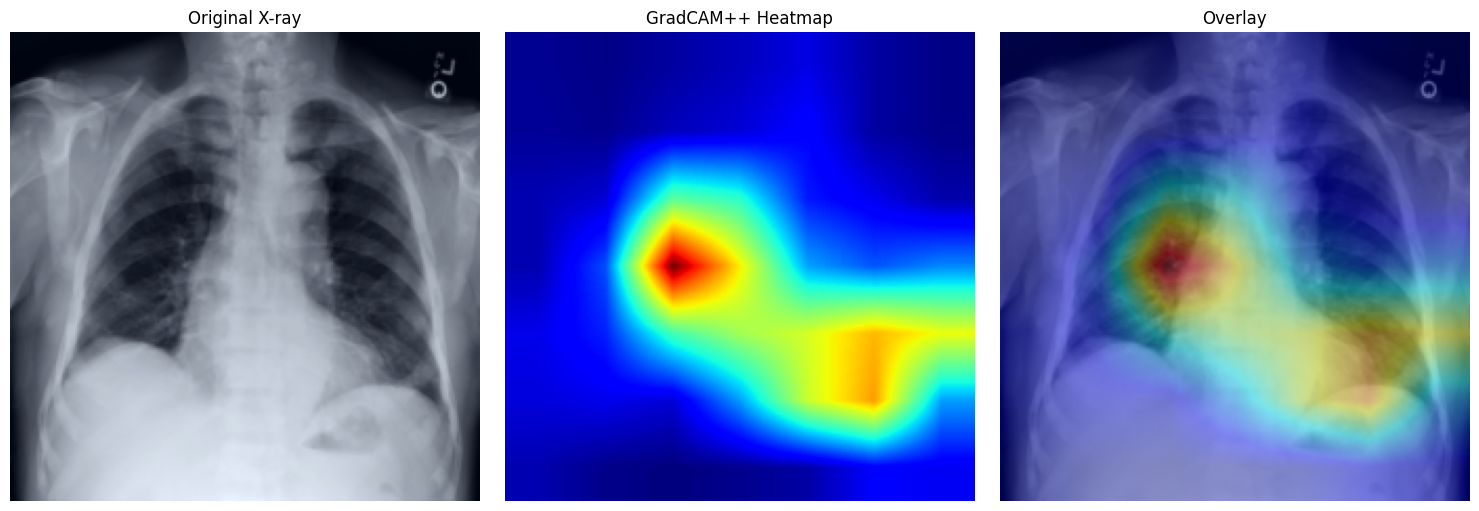

Saved!


In [20]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Get original image
img_tensor = images[0]
original = img_tensor.permute(1, 2, 0).cpu().numpy()
original = (original - original.min()) / (original.max() - original.min())
original = (original * 255).astype(np.uint8)

# Generate overlay
overlay, heatmap_resized = gradcam_pp.overlay(heatmap, original)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original)
axes[0].set_title('Original X-ray')
axes[0].axis('off')

axes[1].imshow(heatmap_resized, cmap='jet')
axes[1].set_title('GradCAM++ Heatmap')
axes[1].axis('off')

axes[2].imshow(overlay)
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('D:/cxr-triage/gradcam_test.png', dpi=150)
plt.show()
print("Saved!")

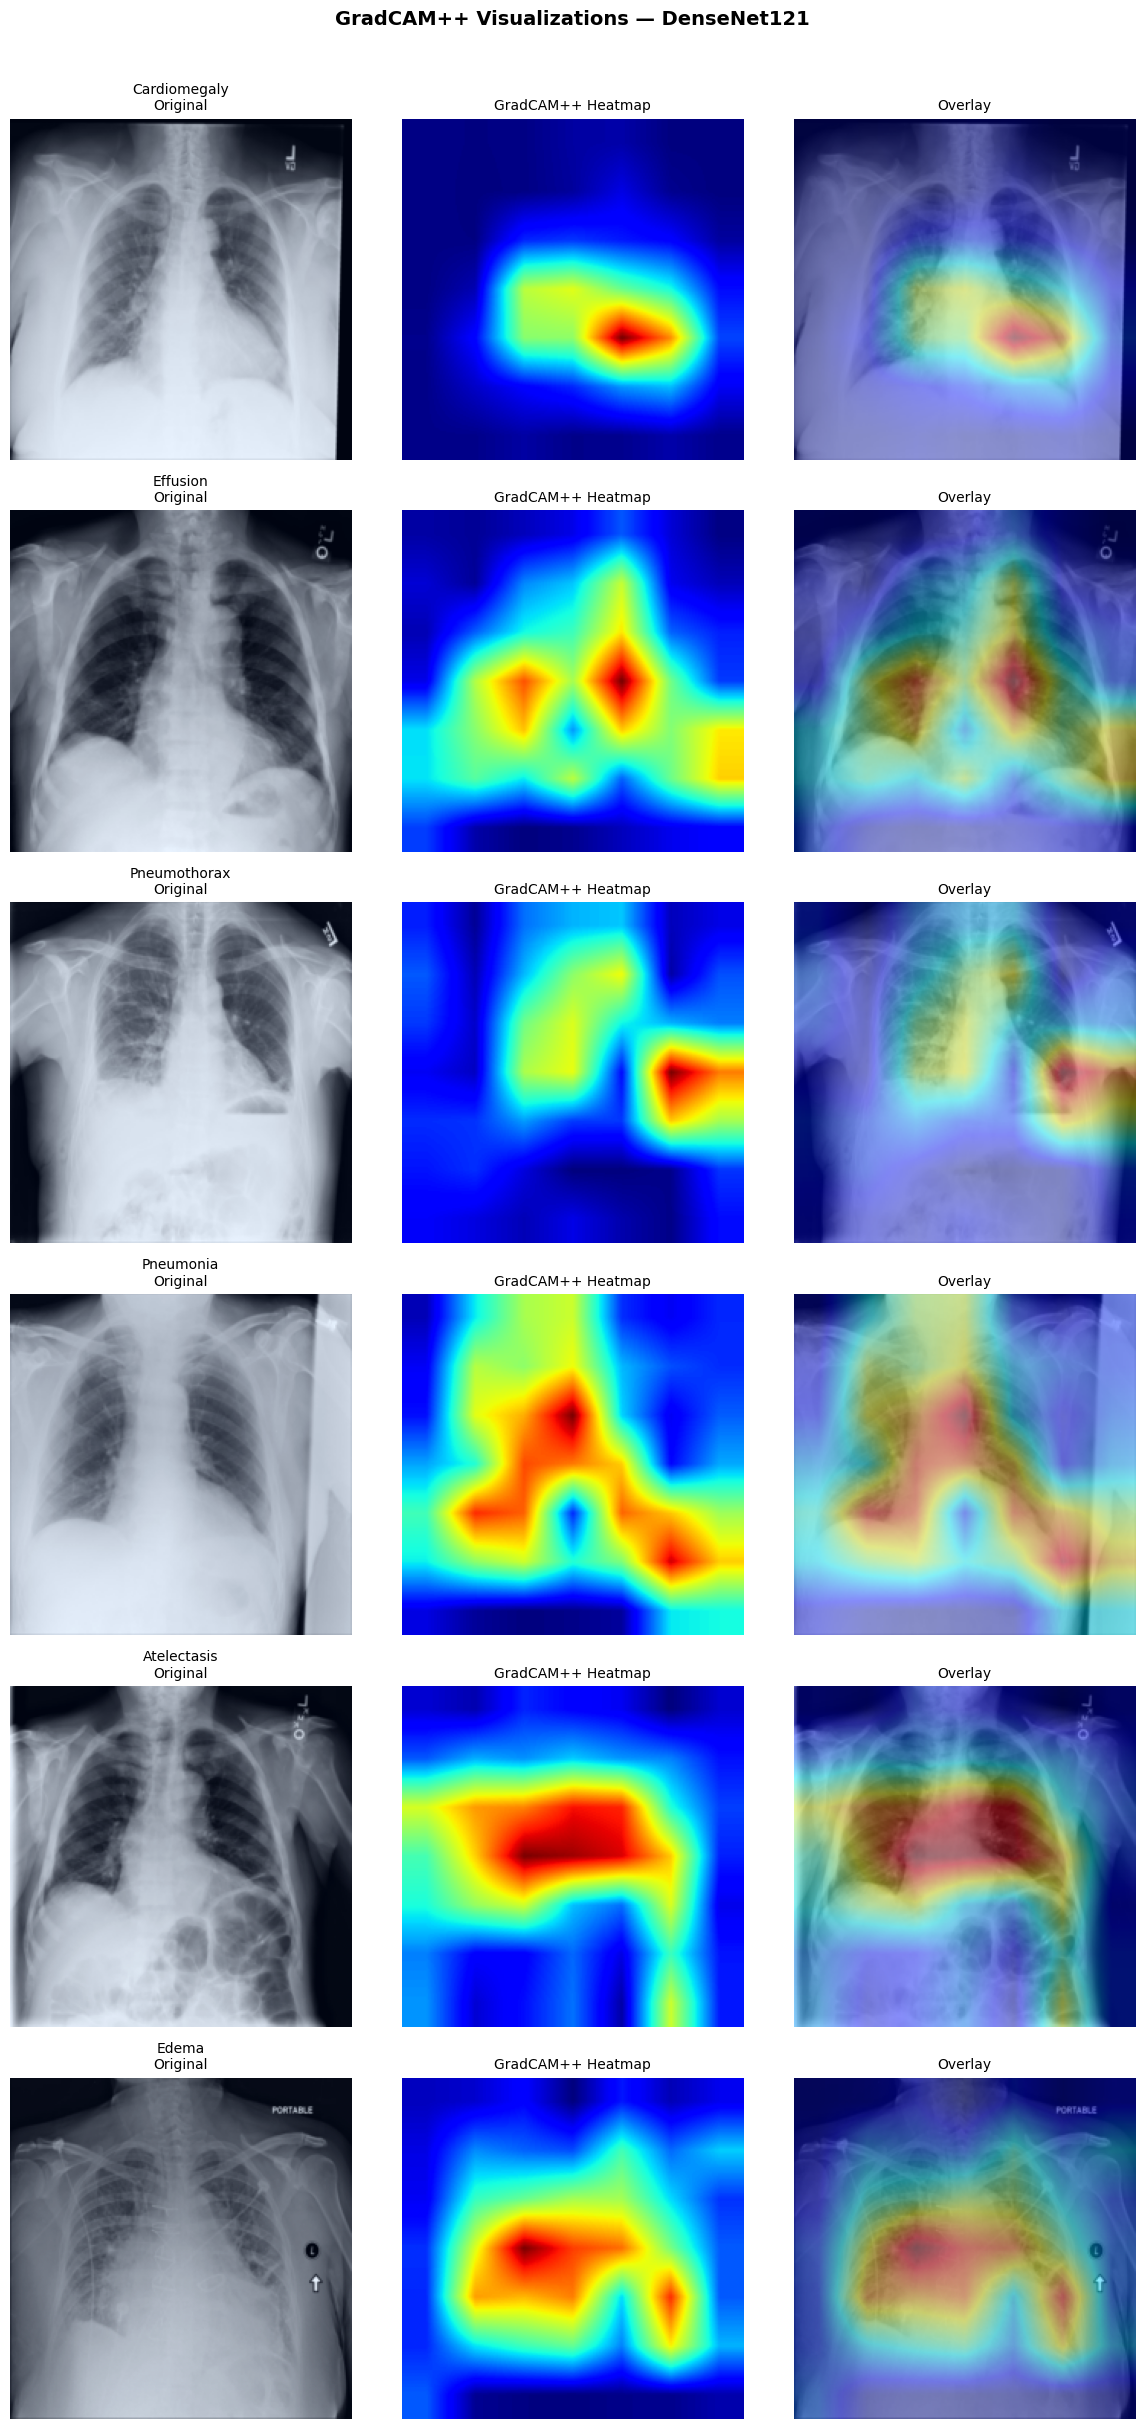

Saved to D:/cxr-triage/gradcam_multiclass.png


In [21]:

import matplotlib.pyplot as plt
import numpy as np
import torch
from src.inference.gradcam import GradCAMPlusPlus

LABELS = [
    'Atelectasis', 'Consolidation', 'Infiltration',
    'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis',
    'Effusion', 'Pneumonia', 'Pleural_Thickening',
    'Cardiomegaly', 'Nodule', 'Mass', 'Hernia'
]

gradcam_pp = GradCAMPlusPlus(model)

def get_sample_for_class(loader, class_idx, max_batches=20):
    """Find an image where the label for class_idx is positive."""
    for i, (images, labels) in enumerate(loader):
        if i >= max_batches:
            break
        for j in range(len(images)):
            if labels[j, class_idx].item() == 1:
                return images[j].unsqueeze(0), labels[j]
    return None, None

def tensor_to_rgb(img_tensor):
    img = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    return (img * 255).astype(np.uint8)

# Classes to visualize
target_classes = {
    'Cardiomegaly': 10,
    'Effusion': 7,
    'Pneumothorax': 3,
    'Pneumonia': 8,
    'Atelectasis': 0,
    'Edema': 4,
}

fig, axes = plt.subplots(len(target_classes), 3, figsize=(12, 4 * len(target_classes)))

for row, (class_name, class_idx) in enumerate(target_classes.items()):
    img_tensor, label = get_sample_for_class(val_loader, class_idx)
    
    if img_tensor is None:
        print(f"No positive sample found for {class_name}")
        continue

    original = tensor_to_rgb(img_tensor)
    heatmap = gradcam_pp.generate(img_tensor, class_idx=class_idx)
    overlay, heatmap_resized = gradcam_pp.overlay(heatmap, original)

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f'{class_name}\nOriginal', fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(heatmap_resized, cmap='jet')
    axes[row, 1].set_title('GradCAM++ Heatmap', fontsize=10)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title('Overlay', fontsize=10)
    axes[row, 2].axis('off')

plt.suptitle('GradCAM++ Visualizations — DenseNet121', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('D:/cxr-triage/gradcam_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to D:/cxr-triage/gradcam_multiclass.png")


In [24]:
bbox_df = pd.read_csv(
    'F:/X ray dataset/Second Version/BBox_List_2017.csv',
    names=['image_index', 'finding_label', 'x', 'y', 'w', 'h'],
    skiprows=1,
    usecols=[0, 1, 2, 3, 4, 5]
)
print(bbox_df.head())
print(f"Total: {len(bbox_df)}")
print(f"Classes: {bbox_df['finding_label'].unique()}")

        image_index finding_label           x           y           w  \
0  00013118_008.png   Atelectasis  225.084746  547.019217   86.779661   
1  00014716_007.png   Atelectasis  686.101695  131.543498  185.491525   
2  00029817_009.png   Atelectasis  221.830508  317.053115  155.118644   
3  00014687_001.png   Atelectasis  726.237288  494.951420  141.016949   
4  00017877_001.png   Atelectasis  660.067797  569.780787  200.677966   

            h  
0   79.186441  
1  313.491525  
2  216.949153  
3   55.322034  
4   78.101695  
Total: 984
Classes: ['Atelectasis' 'Cardiomegaly' 'Effusion' 'Infiltrate' 'Mass' 'Nodule'
 'Pneumonia' 'Pneumothorax']


In [29]:
bbox_df = pd.read_csv(
    'F:/X ray dataset/Second Version/BBox_List_2017.csv',
    names=['image_index', 'finding_label', 'x', 'y', 'w', 'h'],
    skiprows=1,
    usecols=[0, 1, 2, 3, 4, 5]
)
print(bbox_df.columns.tolist())
print(bbox_df.head(2))

['image_index', 'finding_label', 'x', 'y', 'w', 'h']
        image_index finding_label           x           y           w  \
0  00013118_008.png   Atelectasis  225.084746  547.019217   86.779661   
1  00014716_007.png   Atelectasis  686.101695  131.543498  185.491525   

            h  
0   79.186441  
1  313.491525  


In [30]:
sample = bbox_df[bbox_df['finding_label'] == 'Cardiomegaly'].iloc[0]
print(sample)

image_index      00005066_030.png
finding_label        Cardiomegaly
x                      277.152542
y                       459.15481
w                       540.20339
h                      301.559322
Name: 161, dtype: object


In [32]:
import os
base = "F:/X ray dataset/Second Version"
print(os.listdir(base))

['ARXIV_V5_CHESTXRAY.pdf', 'BBox_List_2017.csv', 'Data_Entry_2017.csv', 'FAQ_CHESTXRAY.pdf', 'LOG_CHESTXRAY.pdf', 'README_CHESTXRAY.pdf', 'images_001', 'images_002', 'images_003', 'images_004', 'images_005', 'images_006', 'images_007', 'images_008', 'images_009', 'images_010', 'images_011', 'images_012', 'test_list.txt', 'train_val_list.txt']


In [33]:

import os

def find_image(image_name, base_root):
    for folder in os.listdir(base_root):
        if folder.startswith('images_'):
            path = os.path.join(base_root, folder, 'images', image_name)
            if os.path.exists(path):
                return path
    return None

base = "F:/X ray dataset/Second Version"
path = find_image('00005066_030.png', base)
print(path)

F:/X ray dataset/Second Version\images_003\images\00005066_030.png


Image size: 1024 x 1024


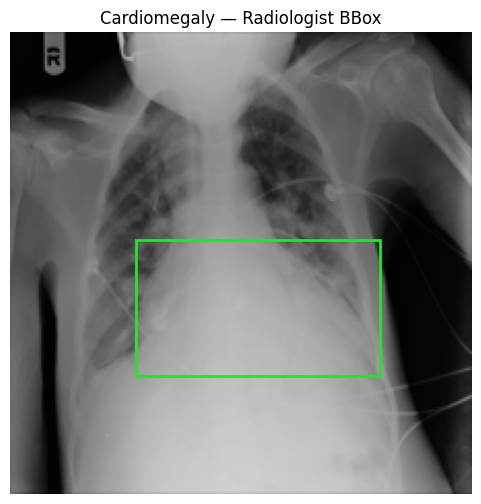

In [34]:
IMAGE_ROOT = "F:/X ray dataset/Second Version\images_003\images"

img = Image.open(f"{IMAGE_ROOT}/00005066_030.png").convert('RGB')
orig_w, orig_h = img.size
print(f"Image size: {orig_w} x {orig_h}")

original = np.array(img.resize((224, 224)))
scale_x = 224 / orig_w
scale_y = 224 / orig_h

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(original)
rect = patches.Rectangle(
    (sample['x'] * scale_x, sample['y'] * scale_y),
    sample['w'] * scale_x, sample['h'] * scale_y,
    linewidth=2, edgecolor='lime', facecolor='none'
)
ax.add_patch(rect)
ax.set_title('Cardiomegaly — Radiologist BBox')
ax.axis('off')
plt.show()

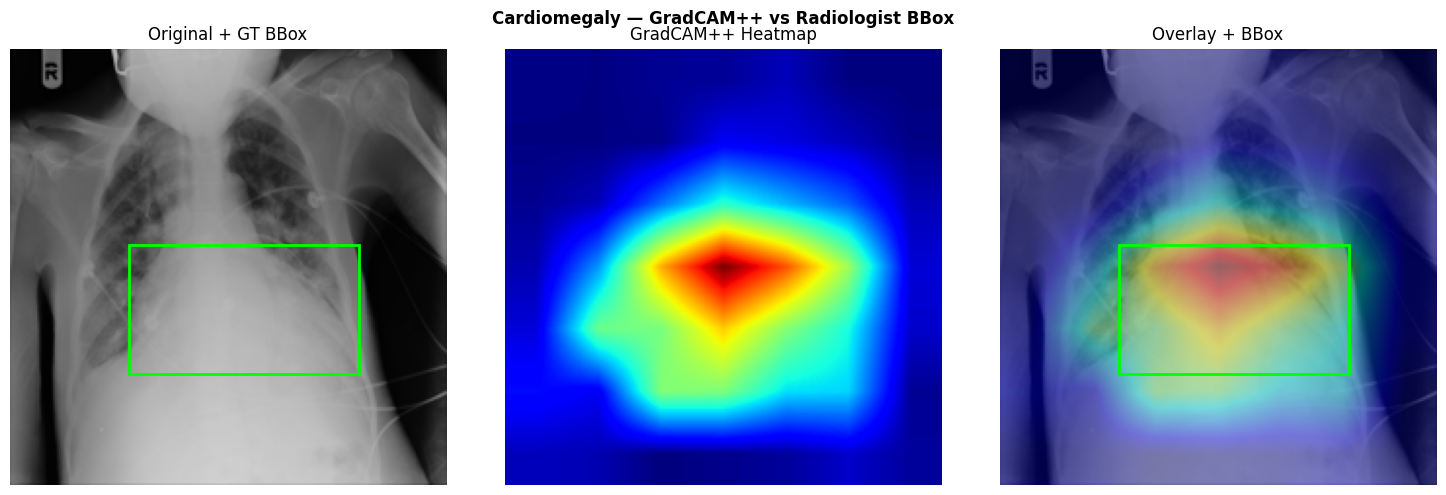

In [35]:
gradcam_pp = GradCAMPlusPlus(model)
transform = get_val_transforms()

img = Image.open(path).convert('RGB')
orig_w, orig_h = img.size
img_tensor = transform(img).unsqueeze(0)
original = np.array(img.resize((224, 224)))

heatmap = gradcam_pp.generate(img_tensor, class_idx=10)
overlay, heatmap_resized = gradcam_pp.overlay(heatmap, original)

scale_x = 224 / orig_w
scale_y = 224 / orig_h

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original)
rect = patches.Rectangle(
    (sample['x'] * scale_x, sample['y'] * scale_y),
    sample['w'] * scale_x, sample['h'] * scale_y,
    linewidth=2, edgecolor='lime', facecolor='none'
)
axes[0].add_patch(rect)
axes[0].set_title('Original + GT BBox')
axes[0].axis('off')

axes[1].imshow(heatmap_resized, cmap='jet')
axes[1].set_title('GradCAM++ Heatmap')
axes[1].axis('off')

axes[2].imshow(overlay)
rect2 = patches.Rectangle(
    (sample['x'] * scale_x, sample['y'] * scale_y),
    sample['w'] * scale_x, sample['h'] * scale_y,
    linewidth=2, edgecolor='lime', facecolor='none'
)
axes[2].add_patch(rect2)
axes[2].set_title('Overlay + BBox')
axes[2].axis('off')

plt.suptitle('Cardiomegaly — GradCAM++ vs Radiologist BBox', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/cxr-triage/gradcam_bbox_cardiomegaly.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def compute_iou(heatmap, x, y, w, h, orig_size=1024, threshold=0.5):
    """Compute IoU between thresholded heatmap and bounding box."""
    heatmap_resized = cv2.resize(heatmap, (orig_size, orig_size))
    binary_heatmap = (heatmap_resized >= threshold).astype(np.float32)
    
    bbox_mask = np.zeros((orig_size, orig_size), dtype=np.float32)
    x1, y1 = int(x), int(y)
    x2, y2 = int(x + w), int(y + h)
    bbox_mask[y1:y2, x1:x2] = 1.0
    
    intersection = (binary_heatmap * bbox_mask).sum()
    union = np.clip(binary_heatmap + bbox_mask, 0, 1).sum()
    
    return intersection / (union + 1e-8)

def visualize_with_bbox(image_name, finding_label, class_idx, bbox_df, image_root, model, gradcam_pp):
    rows = bbox_df[(bbox_df['image_index'] == image_name) & 
                   (bbox_df['finding_label'] == finding_label)]
    if rows.empty:
        print(f"No bbox found for {image_name}")
        return

    img_path = f"{image_root}/{image_name}"
    img = Image.open(img_path).convert('RGB')
    orig_w, orig_h = img.size

    transform = get_val_transforms()
    img_tensor = transform(img).unsqueeze(0)

    original = np.array(img.resize((224, 224)))
    heatmap = gradcam_pp.generate(img_tensor, class_idx=class_idx)
    overlay, heatmap_resized = gradcam_pp.overlay(heatmap, original)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original + bbox
    axes[0].imshow(original)
    for _, row in rows.iterrows():
        scale_x = 224 / orig_w
        scale_y = 224 / orig_h
        rect = patches.Rectangle(
            (row['x'] * scale_x, row['y'] * scale_y),
            row['w'] * scale_x, row['h'] * scale_y,
            linewidth=2, edgecolor='lime', facecolor='none', label='Radiologist bbox'
        )
        axes[0].add_patch(rect)
    axes[0].set_title(f'{finding_label}\nOriginal + GT BBox', fontsize=10)
    axes[0].axis('off')

    # Heatmap
    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title('GradCAM++ Heatmap', fontsize=10)
    axes[1].axis('off')

    # Overlay + bbox
    axes[2].imshow(overlay)
    for _, row in rows.iterrows():
        rect = patches.Rectangle(
            (row['x'] * scale_x, row['y'] * scale_y),
            row['w'] * scale_x, row['h'] * scale_y,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        axes[2].add_patch(rect)
    
    iou = compute_iou(heatmap, rows.iloc[0]['x'] * 224/orig_w,
                      rows.iloc[0]['y'] * 224/orig_h,
                      rows.iloc[0]['w'] * 224/orig_w,
                      rows.iloc[0]['h'] * 224/orig_h, orig_size=224)
    
    axes[2].set_title(f'Overlay + BBox\nIoU: {iou:.3f}', fontsize=10)
    axes[2].axis('off')

    plt.suptitle(f'{image_name} — {finding_label}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'D:/cxr-triage/gradcam_bbox_{finding_label}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return iou

# Test on one image
IMAGE_ROOT = "F:/X ray dataset/Second Version/images"
sample = bbox_df[bbox_df['finding_label'] == 'Cardiomegaly'].iloc[0]
iou = visualize_with_bbox(
    sample['image_index'], 'Cardiomegaly', 10,
    bbox_df, IMAGE_ROOT, model, gradcam_pp
)
print(f"IoU: {iou:.3f}")

Found: F:/X ray dataset/Second Version\images_003\images\00005066_030.png


FileNotFoundError: [Errno 2] No such file or directory: 'F:/X ray dataset/Second Version\\images_003\\images\\00005066_030.png/00005066_030.png'